# Astronomical Coordinate Systems
## A practical guide using Gaia DR2 stars with astropy

**Data:** Gaia Data Release 2 (Gaia DR2)  
**Subsample:** Stars with $16 \leq G < 17$ mag (~78.9 million stars, 13.4 GB)  
**Paper:** Gaia Collaboration, Brown et al. (2018), A&A 616, A1  
**arXiv:** [1804.09365](https://arxiv.org/abs/1804.09365)  
**Gaia Archive:** [https://gea.esac.esa.int/archive/](https://gea.esac.esa.int/archive/)

**Key tool:** `astropy` — [https://docs.astropy.org/en/stable/coordinates/index.html](https://docs.astropy.org/en/stable/coordinates/index.html)

---

## Learning objectives

After this tutorial you will be able to:
1. Explain the main astronomical coordinate systems: **ICRS**, **Galactic**, **Ecliptic**, and **Alt-Az**.
2. Use `astropy.coordinates.SkyCoord` to **convert** between coordinate systems.
3. Understand **proper motion** and **parallax** from Gaia astrometry.
4. Visualise star positions in **multiple sky projections** using matplotlib.
5. Build a **stellar density map** using HEALPix pixelisation.

---

## 1. Why do we need coordinate systems?

The position of a star on the sky depends on the **reference frame** — the choice of origin, equator, and zero-point of longitude. Astronomers use different systems for different purposes:

| System | Equator | Pole | Zero longitude | Best for |
|--------|---------|------|----------------|---------|
| **Equatorial (ICRS)** | Celestial equator | North celestial pole | Vernal equinox | Telescope pointing, star catalogs |
| **Galactic** | Galactic plane | North Galactic pole | Galactic centre | Milky Way structure |
| **Ecliptic** | Ecliptic plane | Ecliptic pole | Vernal equinox | Solar system, planet orbits |
| **Horizontal (Alt-Az)** | Horizon | Zenith | North | Local observations |

---

## 2. The equatorial system: ICRS

The **International Celestial Reference System (ICRS)** is the standard for modern astronomy. It is centred on the solar system barycentre and defined by the positions of distant quasars.

The two coordinates are:
- **Right Ascension (RA, $\alpha$):** Measured **eastward** from the vernal equinox ($\gamma$), from $0^\rm h$ to $24^\rm h$ (or $0°$ to $360°$). Think of it as astronomical longitude.
- **Declination (Dec, $\delta$):** Measured **from** the celestial equator, from $-90°$ to $+90°$. Think of it as astronomical latitude.

The reference epoch for Gaia DR2 is **J2015.5** (positions at 2016 January 1.5).

### Converting to hours:minutes:seconds

RA is often expressed in sexagesimal format:
$$\alpha = h^\rm h\ m^\rm m\ s^\rm s$$
where $1^\rm h = 15°$, $1^\rm m = 0.25°$, $1^\rm s = 0.0042°$.

Dec uses degrees:arcminutes:arcseconds:
$$\delta = \pm d°\ m'\ s''$$

---

## 3. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

# astropy: the core library for astronomical computations in Python
# Documentation: https://docs.astropy.org/en/stable/
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table

# healpy: HEALPix sphere pixelisation
import healpy as hp

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
})

print('Imports successful!')
import astropy
print(f'astropy version: {astropy.__version__}')

Imports successful!
astropy version: 7.2.0


---

## 4. Loading the Gaia DR2 catalog

### 4.1 About Gaia DR2

**Gaia** is a European Space Agency (ESA) astrometric space mission that surveys the entire sky from the L2 Lagrange point. **Gaia Data Release 2 (DR2)**, published in April 2018, contains:
- Positions, parallaxes, and proper motions for **1.33 billion** sources
- Three-band photometry (G, BP, RP) for all sources
- Astrometric precision of **~0.1 mas** for bright sources

Reference: Gaia Collaboration, Brown et al. (2018), A&A 616, A1  
arXiv: [1804.09365](https://arxiv.org/abs/1804.09365)

### 4.2 File description

The file `table_16_g_17.fits` contains stars with **$16 \leq G < 17$** magnitudes.

| Column | Unit | Description |
|--------|------|-------------|
| `source_id` | — | Gaia unique identifier |
| `ref_epoch` | yr | Reference epoch (J2015.5) |
| `ra`, `ra_error` | deg, mas | Right Ascension and uncertainty |
| `dec`, `dec_error` | deg, mas | Declination and uncertainty |
| `parallax`, `parallax_error` | mas, mas | Trigonometric parallax |
| `pmra`, `pmra_error` | mas/yr, mas/yr | Proper motion in RA |
| `pmdec`, `pmdec_error` | mas/yr, mas/yr | Proper motion in Dec |
| `phot_g_mean_mag` | mag | G-band mean magnitude |
| `phot_bp_mean_mag` | mag | BP-band mean magnitude |
| `phot_rp_mean_mag` | mag | RP-band mean magnitude |

### 4.3 Memory management: why we subsample

The full catalog contains **78.9 million** stars and is 13.4 GB. Loading it entirely would require ~10 GB of RAM. We use two strategies:
1. **`memmap=True`** in FITS: the file is memory-mapped — data is read from disk on demand.
2. **Strided sampling**: we take every $N$th row to get a representative subsample.

In [2]:
GAIA_FILE = '/home/comparat/data/gaia_cat/table_16_g_17.fits'
# Subsample of Gaia DR2 limited to 16 <= G < 17 mag (~78.9 M stars total)

# Open with memmap=True: data stays on disk until accessed
hdul = fits.open(GAIA_FILE, memmap=True)
data_full = hdul[1].data
N_TOTAL = len(data_full)
print(f'Total stars in file: {N_TOTAL:,}')
print(f'File size (on disk): ~{N_TOTAL * 170 / 1e9:.1f} GB  (170 bytes/row)')

# Take a uniform subsample: every 789th star => ~100,000 stars
N_SAMPLE = 100_000
stride = N_TOTAL // N_SAMPLE
idx = np.arange(0, N_TOTAL, stride)[:N_SAMPLE]

print(f'\nUsing subsample: {len(idx):,} stars  (1 in every {stride} stars)')

# Extract relevant columns into numpy arrays
ra      = data_full['ra'][idx].astype(np.float64)         # degrees
dec     = data_full['dec'][idx].astype(np.float64)        # degrees
plx     = data_full['parallax'][idx].astype(np.float64)   # mas
plx_err = data_full['parallax_error'][idx].astype(np.float64)  # mas
pmra    = data_full['pmra'][idx].astype(np.float64)       # mas/yr
pmdec   = data_full['pmdec'][idx].astype(np.float64)      # mas/yr
G_mag   = data_full['phot_g_mean_mag'][idx].astype(np.float64)  # mag
BP_mag  = data_full['phot_bp_mean_mag'][idx].astype(np.float64) # mag
RP_mag  = data_full['phot_rp_mean_mag'][idx].astype(np.float64) # mag

hdul.close()

print(f'\nCoordinate ranges:')
print(f'  RA  : {ra.min():.2f}° – {ra.max():.2f}°')
print(f'  Dec : {dec.min():.2f}° – {dec.max():.2f}°')
print(f'  G   : {np.nanmin(G_mag):.2f} – {np.nanmax(G_mag):.2f} mag')

Total stars in file: 78,920,842
File size (on disk): ~13.4 GB  (170 bytes/row)

Using subsample: 100,000 stars  (1 in every 789 stars)



Coordinate ranges:
  RA  : 0.01° – 359.99°
  Dec : -89.76° – 89.60°
  G   : 16.00 – 17.00 mag


---

## 5. Using `astropy.coordinates.SkyCoord`

`SkyCoord` is the main astropy class for representing positions on the sky. It:
- Accepts positions in many formats (degrees, radians, hours, sexagesimal)
- Knows which coordinate frame it is in (ICRS, Galactic, etc.)
- Converts between frames automatically
- Supports array operations (vectorised over many stars at once)

Documentation: [https://docs.astropy.org/en/stable/coordinates/index.html](https://docs.astropy.org/en/stable/coordinates/index.html)

### 5.1 Creating a SkyCoord object

In [3]:
# Create SkyCoord from the Gaia (RA, Dec) in the ICRS frame
# 'frame=icrs' is the default and can be omitted
coords_icrs = SkyCoord(
    ra  = ra  * u.deg,
    dec = dec * u.deg,
    frame = 'icrs'
)

print(f'SkyCoord object: {len(coords_icrs)} stars')
print(f'Frame: {coords_icrs.frame.name}')
print()

# Show the first 5 stars
print('First 5 stars (RA, Dec in degrees):')
for i in range(5):
    c = coords_icrs[i]
    print(f'  Star {i+1}: RA={c.ra.deg:.4f}  Dec={c.dec.deg:.4f} deg')
    print(f'           RA={c.ra.to_string(unit=u.hourangle, sep=":")}  Dec={c.dec.to_string(sep=":")} (sexagesimal)')

SkyCoord object: 100000 stars
Frame: icrs

First 5 stars (RA, Dec in degrees):
  Star 1: RA=105.1288  Dec=56.2851 deg
           RA=7:00:30.92391222  Dec=56:17:06.29129866 (sexagesimal)
  Star 2: RA=103.5644  Dec=56.3105 deg
           RA=6:54:15.45220233  Dec=56:18:37.82775205 (sexagesimal)
  Star 3: RA=104.6572  Dec=57.2099 deg
           RA=6:58:37.71736588  Dec=57:12:35.75850546 (sexagesimal)
  Star 4: RA=103.0924  Dec=58.3645 deg
           RA=6:52:22.16442127  Dec=58:21:52.14991991 (sexagesimal)
  Star 5: RA=103.5463  Dec=57.4587 deg
           RA=6:54:11.12363417  Dec=57:27:31.41860504 (sexagesimal)


In [4]:
# Example: the galactic centre at (RA=266.405, Dec=-28.936) deg
gc = SkyCoord(ra=266.405*u.deg, dec=-28.936*u.deg, frame='icrs')

print('== Galactic Centre in different formats ==')
print(f'ICRS (degrees) : RA = {gc.ra.deg:.3f}°   Dec = {gc.dec.deg:.3f}°')
print(f'ICRS (hms/dms) : RA = {gc.ra.to_string(unit=u.h, sep=" h ", precision=2)}   Dec = {gc.dec.to_string(sep=" d ", precision=1)}')
print()

# Convert to Galactic (should be l≈0, b≈0)
gc_gal = gc.galactic
print(f'Galactic       : l = {gc_gal.l.deg:.3f}°   b = {gc_gal.b.deg:.3f}°')
print()

# Other special directions
print('== North Galactic Pole ==')
ngp = SkyCoord(l=0*u.deg, b=90*u.deg, frame='galactic')
ngp_icrs = ngp.icrs
print(f'Galactic (l=0, b=90) -> ICRS: RA={ngp_icrs.ra.deg:.3f}°  Dec={ngp_icrs.dec.deg:.3f}°')

print('\n== Vernal Equinox (RA=0, Dec=0) ==')
ve = SkyCoord(ra=0*u.deg, dec=0*u.deg, frame='icrs')
ve_gal = ve.galactic
print(f'ICRS (RA=0, Dec=0) -> Galactic: l={ve_gal.l.deg:.3f}°  b={ve_gal.b.deg:.3f}°')

== Galactic Centre in different formats ==
ICRS (degrees) : RA = 266.405°   Dec = -28.936°
ICRS (hms/dms) : RA = 17 45h37.20    Dec = -28 56d09.6 

Galactic       : l = 0.000°   b = 0.000°

== North Galactic Pole ==
Galactic (l=0, b=90) -> ICRS: RA=192.859°  Dec=27.128°

== Vernal Equinox (RA=0, Dec=0) ==
ICRS (RA=0, Dec=0) -> Galactic: l=96.337°  b=-60.189°


---

## 6. Galactic coordinates

Galactic coordinates $(l, b)$ are defined relative to the **Milky Way** structure:
- **Galactic longitude** $l$: measured eastward along the Galactic plane from the Galactic centre, $0° \leq l < 360°$.
- **Galactic latitude** $b$: measured perpendicular to the Galactic plane, $-90° \leq b \leq +90°$.

The Galactic centre is at $(l, b) = (0°, 0°)$, which corresponds to ICRS $(\alpha, \delta) \approx (266.4°, -29.0°)$.

Galactic coordinates are fundamental for understanding:
- The distribution of stars in the Milky Way disk
- Dust extinction (highest at $|b| < 20°$)
- The velocity structure of the galaxy

In [5]:
# Convert all stars to Galactic coordinates
coords_gal = coords_icrs.galactic

l = coords_gal.l.deg   # Galactic longitude [0, 360)
b = coords_gal.b.deg   # Galactic latitude  [-90, +90]

print(f'Galactic coordinate statistics:')
print(f'  l range : {l.min():.2f}° – {l.max():.2f}°')
print(f'  b range : {b.min():.2f}° – {b.max():.2f}°')
print(f'  |b| < 10° (Galactic plane): {(np.abs(b) < 10).sum():,} stars  ({(np.abs(b) < 10).mean()*100:.1f}%)')
print(f'  |b| > 60° (Galactic poles): {(np.abs(b) > 60).sum():,} stars  ({(np.abs(b) > 60).mean()*100:.1f}%)')
print()
print('First 5 stars:')
for i in range(5):
    print(f'  Star {i+1}: RA={ra[i]:.3f}°  Dec={dec[i]:.3f}°  ->  l={l[i]:.3f}°  b={b[i]:.3f}°')

Galactic coordinate statistics:
  l range : 0.00° – 360.00°
  b range : -89.02° – 89.74°
  |b| < 10° (Galactic plane): 60,934 stars  (60.9%)
  |b| > 60° (Galactic poles): 1,341 stars  (1.3%)

First 5 stars:
  Star 1: RA=105.129°  Dec=56.285°  ->  l=160.148°  b=23.506°
  Star 2: RA=103.564°  Dec=56.311°  ->  l=159.881°  b=22.673°
  Star 3: RA=104.657°  Dec=57.210°  ->  l=159.101°  b=23.481°
  Star 4: RA=103.092°  Dec=58.364°  ->  l=157.658°  b=22.962°
  Star 5: RA=103.546°  Dec=57.459°  ->  l=158.675°  b=22.963°


---

## 7. Ecliptic coordinates

Ecliptic coordinates $(\lambda, \beta)$ are defined relative to the **Earth's orbital plane** (the ecliptic):
- **Ecliptic longitude** $\lambda$: measured along the ecliptic from the vernal equinox.
- **Ecliptic latitude** $\beta$: measured perpendicular to the ecliptic.

The ecliptic is tilted by **23.44°** (the **obliquity** of the ecliptic) relative to the celestial equator.

Ecliptic coordinates are used for:
- Solar system bodies (planets, asteroids, comets) which orbit near the ecliptic
- CMB polarisation studies (the ecliptic defines the zodiacal light)
- Space mission planning

In astropy, the ecliptic frame is called `GeocentricMeanEcliptic` (geocentric ecliptic referred to the mean equinox of date).

In [6]:
from astropy.coordinates import GeocentricMeanEcliptic

# Ecliptic coordinates need an epoch (time when the ecliptic is defined)
# We use the Gaia DR2 reference epoch: J2015.5
t_gaia = Time('J2015.5')

coords_ecl = coords_icrs.transform_to(
    GeocentricMeanEcliptic(equinox=t_gaia)
)

lon_ecl = coords_ecl.lon.deg  # Ecliptic longitude lambda
lat_ecl = coords_ecl.lat.deg  # Ecliptic latitude  beta

print('Ecliptic coordinate statistics:')
print(f'  lambda range: {lon_ecl.min():.2f}° – {lon_ecl.max():.2f}°')
print(f'  beta range  : {lat_ecl.min():.2f}° – {lat_ecl.max():.2f}°')
print(f'  |beta| < 10° (near ecliptic): {(np.abs(lat_ecl) < 10).sum():,} stars')

# Sanity check: the obliquity ~23.44°
equinox = SkyCoord(ra=0*u.deg, dec=0*u.deg, frame='icrs')
equinox_ecl = equinox.transform_to(GeocentricMeanEcliptic(equinox=t_gaia))
print(f'\nVernal equinox in ecliptic: lambda={equinox_ecl.lon.deg:.2f}°  beta={equinox_ecl.lat.deg:.4f}°')
north_pole = SkyCoord(ra=0*u.deg, dec=90*u.deg, frame='icrs')
np_ecl = north_pole.transform_to(GeocentricMeanEcliptic(equinox=t_gaia))
print(f'North celestial pole in ecliptic: lambda={np_ecl.lon.deg:.2f}°  beta={np_ecl.lat.deg:.2f}° (expected ~66.56°)')

Ecliptic coordinate statistics:
  lambda range: 0.01° – 359.99°
  beta range  : -89.80° – 89.14°
  |beta| < 10° (near ecliptic): 20,006 stars

Vernal equinox in ecliptic: lambda=0.22°  beta=0.0002°
North celestial pole in ecliptic: lambda=90.23°  beta=66.56° (expected ~66.56°)


---

## 8. Horizontal (Alt-Az) coordinates

The **horizontal system** describes where an object appears from a specific location on Earth at a specific time:
- **Altitude (Alt):** Angle above the horizon, $-90° \leq {\rm Alt} \leq 90°$. Alt $= 0°$ is the horizon; Alt $= 90°$ is the zenith.
- **Azimuth (Az):** Angle measured clockwise from North, $0° \leq {\rm Az} < 360°$.

This coordinate system **rotates with the Earth** — a star's Alt-Az changes continuously as Earth rotates. This is the system used to point telescopes.

### Key concepts:
- **Meridian transit:** A star reaches maximum altitude when it crosses the meridian (Az $= 0°$ or $180°$).
- **Hour angle (H):** Time since the star last crossed the meridian.
- **Circumpolar stars:** Stars with Dec $> 90° - |\phi|$ (where $\phi$ is the observer's latitude) never set — they are always above the horizon.

To transform to Alt-Az, astropy needs:
1. The **observer's location** (longitude, latitude, altitude)
2. The **time** of observation

In [7]:
# Define an observing site: Max-Planck-Institut für extraterrestrische Physik (MPE), Garching
# Coordinates: lat=48.26°N, lon=11.67°E, alt=523 m
mpe = EarthLocation(
    lat  = 48.26 * u.deg,   # latitude: 48.26°N
    lon  = 11.67 * u.deg,   # longitude: 11.67°E
    height = 523 * u.m      # altitude above sea level
)
print(f'Observer location: MPE Garching')
print(f'  Latitude  : {mpe.lat.deg:.2f}°N')
print(f'  Longitude : {mpe.lon.deg:.2f}°E')
print(f'  Height    : {mpe.height:.0f}')

# Define the observation time
obs_time = Time('2024-06-21 22:00:00', scale='utc')  # Summer solstice, 22:00 UT
print(f'\nObservation time: {obs_time.iso} UTC')
print(f'  Julian Date: {obs_time.jd:.2f}')

# Create the AltAz frame
altaz_frame = AltAz(obstime=obs_time, location=mpe)

# Convert a small subsample (full conversion is fast, just showing principle)
N_ALTAZ = 5_000  # Convert 5,000 stars
coords_small = coords_icrs[:N_ALTAZ]

print(f'\nConverting {N_ALTAZ} stars to Alt-Az...')
coords_altaz = coords_small.transform_to(altaz_frame)

alt = coords_altaz.alt.deg
az  = coords_altaz.az.deg

print(f'  Altitude range: {alt.min():.1f}° – {alt.max():.1f}°')
print(f'  Stars above horizon (Alt > 0°): {(alt > 0).sum():,} / {N_ALTAZ}')

# Show 5 examples
print('\nFirst 5 stars (ICRS → Alt-Az):')
for i in range(5):
    print(f'  RA={ra[i]:7.3f}°  Dec={dec[i]:+7.3f}°  ->  Alt={alt[i]:+6.2f}°  Az={az[i]:6.2f}°  '
          f'({"VISIBLE" if alt[i]>0 else "below horizon"})')

Observer location: MPE Garching
  Latitude  : 48.26°N
  Longitude : 11.67°E
  Height    : 523 m

Observation time: 2024-06-21 22:00:00.000 UTC
  Julian Date: 2460483.42

Converting 5000 stars to Alt-Az...


  Altitude range: -32.9° – 89.4°
  Stars above horizon (Alt > 0°): 4,409 / 5000

First 5 stars (ICRS → Alt-Az):
  RA=105.129°  Dec=+56.285°  ->  Alt=+18.15°  Az=341.24°  (VISIBLE)
  RA=103.564°  Dec=+56.311°  ->  Alt=+17.85°  Az=342.10°  (VISIBLE)
  RA=104.657°  Dec=+57.210°  ->  Alt=+18.91°  Az=341.86°  (VISIBLE)
  RA=103.092°  Dec=+58.364°  ->  Alt=+19.67°  Az=343.14°  (VISIBLE)
  RA=103.546°  Dec=+57.459°  ->  Alt=+18.92°  Az=342.55°  (VISIBLE)


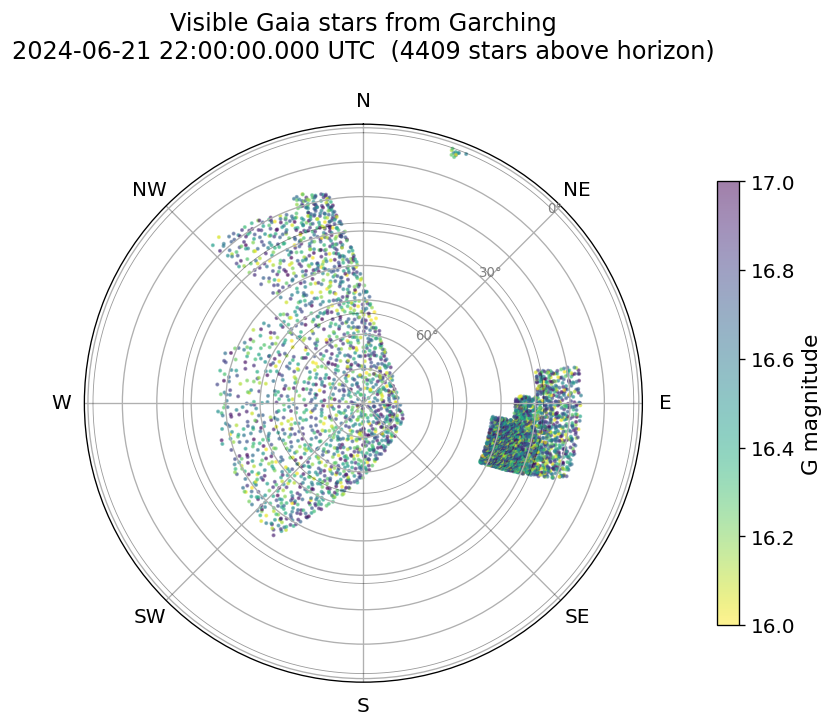

In [8]:
# Visualise the visible sky from Garching in polar projection
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

above = alt > 0

# Convert: azimuth to radians, altitude to angular radius from zenith
az_rad  = np.deg2rad(az[above])
zen_rad = np.deg2rad(90 - alt[above])  # 0 = zenith, pi/2 = horizon

# Colour by G magnitude
sc = ax.scatter(az_rad, zen_rad, c=G_mag[:N_ALTAZ][above],
                cmap='viridis_r', s=2, alpha=0.5, vmin=16, vmax=17)

# Concentric circles: elevation contours
for alt_line in [0, 30, 60]:
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(theta, np.full_like(theta, np.deg2rad(90-alt_line)),
            'k-', lw=0.5, alpha=0.4)
    ax.text(np.pi/4, np.deg2rad(90-alt_line), f'{alt_line}°',
            fontsize=8, color='gray', ha='center')

ax.set_theta_zero_location('N')   # North at top
ax.set_theta_direction(-1)         # Clockwise azimuth
ax.set_ylim(0, np.pi/2 + 0.05)
ax.set_yticklabels([])
ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

plt.colorbar(sc, ax=ax, label='G magnitude', shrink=0.6, pad=0.1)
ax.set_title(f'Visible Gaia stars from Garching\n{obs_time.iso} UTC  ({above.sum()} stars above horizon)',
             pad=20)
plt.savefig('coord_altaz_view.pdf', bbox_inches='tight')
plt.show()

---

## 9. Gaia astrometry: parallax and distance

### 9.1 Trigonometric parallax

**Parallax** is the apparent shift in a star's position caused by Earth's orbital motion around the Sun. As Earth moves from one side of its orbit to the other (a baseline of 2 AU), nearby stars appear to shift against the background of distant stars.

The parallax angle $\varpi$ (in arcseconds) is related to the distance $d$ (in parsec) by:

$$d [\rm pc] = \frac{1}{\varpi [\rm arcsec]} = \frac{1000}{\varpi [\rm mas]}$$

Gaia measures parallaxes in **milliarcseconds (mas)**. For the G=16–17 magnitude range, typical parallaxes are $\varpi \sim 0.5$ mas, corresponding to distances of $\sim 2$ kpc.

> ⚠️ **Caution:** This simple inversion $d = 1/\varpi$ is only valid when the relative parallax uncertainty $\sigma_\varpi/\varpi \ll 1$. For noisy measurements, Bayesian distance estimation is needed (Bailer-Jones et al. 2018).

### 9.2 Proper motion

**Proper motion** is the angular motion of a star across the sky (not its radial velocity). Gaia measures two components:
- $\mu_{\alpha*} = \mu_\alpha \cos\delta$ (`pmra`): proper motion in RA direction [mas/yr]
- $\mu_\delta$ (`pmdec`): proper motion in Dec direction [mas/yr]

The total proper motion is $\mu = \sqrt{\mu_{\alpha*}^2 + \mu_\delta^2}$ [mas/yr].

At a distance of $d$ kpc, a proper motion of $\mu$ mas/yr corresponds to a transverse velocity:
$$v_\perp\,[\rm km/s] = 4.7405 \times \mu\,[\rm mas/yr] \times d\,[\rm kpc]$$

**Origin of the 4.7405 factor:** The definition of the parsec gives $1\,\rm arcsec \times 1\,\rm pc = 1\,\rm AU$. The factors of 1000 from mas$\to$arcsec and from kpc$\to$pc cancel exactly:
$$\mu\,[\rm mas/yr] \times d\,[\rm kpc]
  \times \underbrace{\frac{1\,\rm arcsec}{1000\,\rm mas}}_{\times 10^{-3}}
  \times \underbrace{\frac{1000\,\rm pc}{1\,\rm kpc}}_{\times 10^{3}}
  \times \underbrace{\frac{1\,\rm AU}{1\,\rm arcsec\cdot pc}}_{\text{parsec def.}}
  = \mu \times d\ [\rm AU/yr]$$

So **1 mas/yr at 1 kpc $\equiv$ 1 AU/yr**. Converting AU/yr to km/s:
$$4.7405 = \frac{1\,\rm AU}{1\,\rm yr} = \frac{1.496 \times 10^8\,\rm km}{3.1557 \times 10^7\,\rm s}$$

Expanding all conversion factors explicitly (the 1000s cancel, leaving arcsec$\to$rad and pc$\to$km):
$$v_\perp\,[\rm km/s] = \mu\,[\rm mas/yr] \times d\,[\rm kpc]
  \times \frac{\pi}{180 \times 3600}
  \times \frac{1\,\rm pc\,in\,km}{1\,\rm yr\,in\,s}$$
with $1\,\rm pc = 3.0857 \times 10^{13}\,\rm km$ and $1\,\rm yr = 3.1557 \times 10^7\,\rm s$, giving the coefficient $4.7405\,\rm km/s$ per $\rm mas/yr$ per $\rm kpc$.

In [9]:
# Select stars with reliable parallax: signal-to-noise > 5
good_plx = np.isfinite(plx) & np.isfinite(plx_err) & (plx_err > 0) & (plx / plx_err > 5)
good_pm  = np.isfinite(pmra) & np.isfinite(pmdec)

print(f'Stars with reliable parallax (S/N > 5): {good_plx.sum():,}  ({good_plx.mean()*100:.1f}%)')
print(f'Stars with proper motion data         : {good_pm.sum():,}  ({good_pm.mean()*100:.1f}%)')

# Distance estimate (only for good parallaxes)
plx_good = plx[good_plx]  # mas
dist_kpc  = 1.0 / plx_good  # kpc  (valid when S/N > 5)

print(f'\nDistance statistics (1/parallax, S/N>5 stars):')
print(f'  Median distance : {np.median(dist_kpc):.2f} kpc')
print(f'  Mean distance   : {np.mean(dist_kpc):.2f} kpc')
print(f'  10th percentile : {np.percentile(dist_kpc, 10):.2f} kpc')
print(f'  90th percentile : {np.percentile(dist_kpc, 90):.2f} kpc')

# Proper motion total
pm_tot = np.sqrt(pmra**2 + pmdec**2)
good_both = good_plx & good_pm

# Transverse velocity
v_trans = 4.74 * pm_tot[good_both] * (1.0 / plx[good_both])  # km/s

print(f'\nProper motion statistics:')
print(f'  Median |mu| : {np.nanmedian(pm_tot):.2f} mas/yr')
print(f'  Median v_t  : {np.nanmedian(v_trans):.1f} km/s  (transverse velocity)')

Stars with reliable parallax (S/N > 5): 48,935  (48.9%)
Stars with proper motion data         : 98,781  (98.8%)

Distance statistics (1/parallax, S/N>5 stars):
  Median distance : 1.67 kpc
  Mean distance   : 1.71 kpc
  10th percentile : 0.67 kpc
  90th percentile : 2.79 kpc

Proper motion statistics:
  Median |mu| : 5.76 mas/yr
  Median v_t  : 47.7 km/s  (transverse velocity)


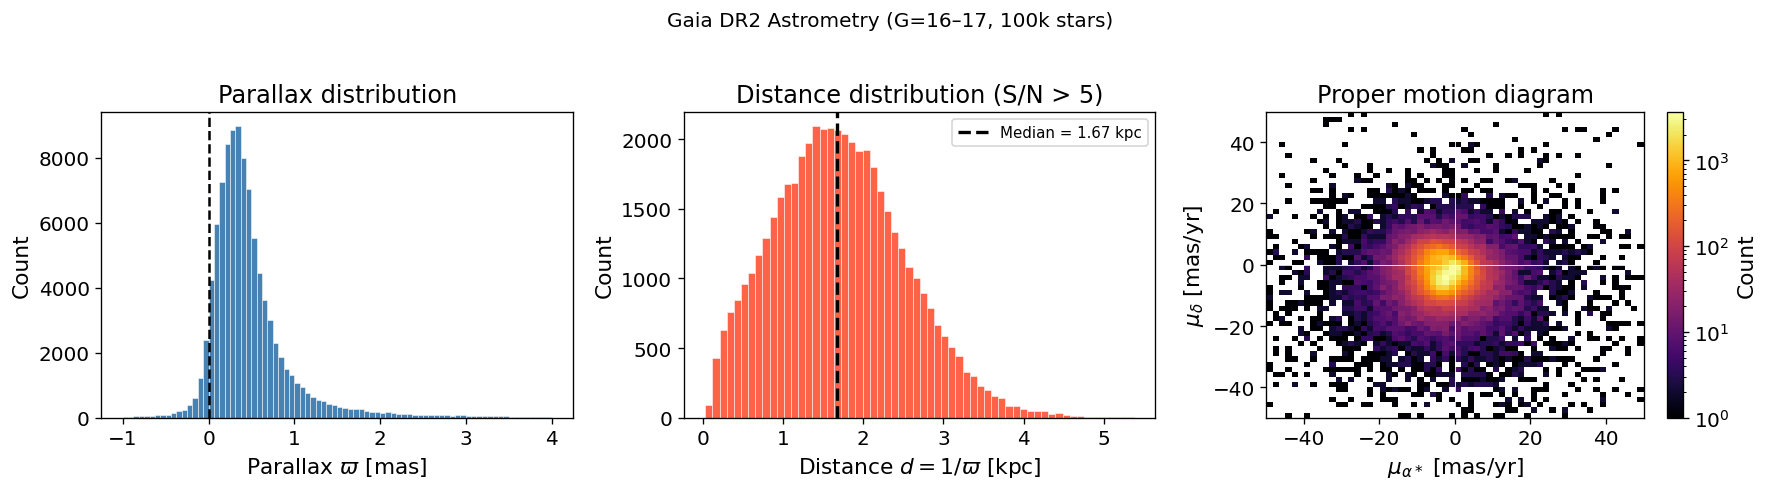

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Parallax distribution
ax = axes[0]
ax.hist(plx[np.isfinite(plx)], bins=80, range=(-1, 4), color='steelblue', edgecolor='w', lw=0.3)
ax.axvline(0, color='k', lw=1.5, ls='--')
ax.set_xlabel('Parallax $\\varpi$ [mas]')
ax.set_ylabel('Count')
ax.set_title('Parallax distribution')

# Distance distribution (reliable parallaxes only)
ax = axes[1]
ax.hist(dist_kpc[dist_kpc < 10], bins=60, color='tomato', edgecolor='w', lw=0.3)
ax.axvline(np.median(dist_kpc), color='k', lw=2, ls='--', label=f'Median = {np.median(dist_kpc):.2f} kpc')
ax.set_xlabel('Distance $d = 1/\\varpi$ [kpc]')
ax.set_ylabel('Count')
ax.set_title('Distance distribution (S/N > 5)')
ax.legend(fontsize=9)

# Proper motion diagram
ax = axes[2]
mask_pm = good_pm & (np.abs(pmra) < 50) & (np.abs(pmdec) < 50)
h = ax.hist2d(pmra[mask_pm], pmdec[mask_pm], bins=60, cmap='inferno',
              norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Count')
ax.set_xlabel(r'$\mu_{\alpha*}$ [mas/yr]')
ax.set_ylabel(r'$\mu_\delta$ [mas/yr]')
ax.set_title('Proper motion diagram')
ax.axhline(0, color='w', lw=0.5)
ax.axvline(0, color='w', lw=0.5)

plt.suptitle('Gaia DR2 Astrometry (G=16–17, 100k stars)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coord_astrometry.pdf', bbox_inches='tight')
plt.show()

---

## 10. Sky maps in different projections

Representing the full celestial sphere on a flat map requires a **projection**. Different projections preserve different properties (area, shape, distance). Astronomy commonly uses:

| Projection | Equal-area? | Shape-preserving? | Use case |
|-----------|-------------|-------------------|----------|
| **Mollweide** | Yes | No | All-sky surveys, CMB maps |
| **Aitoff** | Compromise | Partial | All-sky star catalogs |
| **Hammer** | Yes | No | All-sky surveys |
| **Lambert** | Yes (azimuthal) | No | Polar views |
| **Gnomonic** | No | Great circles → lines | Small fields |

matplotlib supports all of these as axis projections. The standard convention in astronomy:
- **RA increases to the left** (mirrored from the terrestrial convention)
- Coordinates in radians, centred at RA = 180° (or l = 180° for Galactic)

### Converting coordinates for matplotlib projections

matplotlib expects:
- Longitude: $-\pi \leq \phi \leq +\pi$, with $\phi = 0$ at the map centre
- Latitude: $-\pi/2 \leq \theta \leq +\pi/2$

In [11]:
def sky_for_mpl(longitude_deg, latitude_deg, center_deg=180.0):
    """Convert sky coordinates to matplotlib projection convention.

    Parameters
    ----------
    longitude_deg : array [0, 360)
    latitude_deg  : array [-90, +90]
    center_deg    : central longitude of the map

    Returns
    -------
    x, y : radians suitable for matplotlib projections
    """
    lon = np.deg2rad(longitude_deg - center_deg)
    # Wrap to (-pi, +pi]
    lon = (lon + np.pi) % (2 * np.pi) - np.pi
    lat = np.deg2rad(latitude_deg)
    # RA increases to the left => flip sign
    return -lon, lat

# Prepare coordinates for plotting
x_eq, y_eq = sky_for_mpl(ra, dec)       # ICRS
x_gal, y_gal = sky_for_mpl(l, b)        # Galactic
x_ecl, y_ecl = sky_for_mpl(lon_ecl, lat_ecl)  # Ecliptic

print('Coordinates prepared for matplotlib projections.')
print(f'  x_eq range : {x_eq.min():.2f} – {x_eq.max():.2f} rad')
print(f'  y_eq range : {y_eq.min():.2f} – {y_eq.max():.2f} rad')

Coordinates prepared for matplotlib projections.
  x_eq range : -3.14 – 3.14 rad
  y_eq range : -1.57 – 1.56 rad


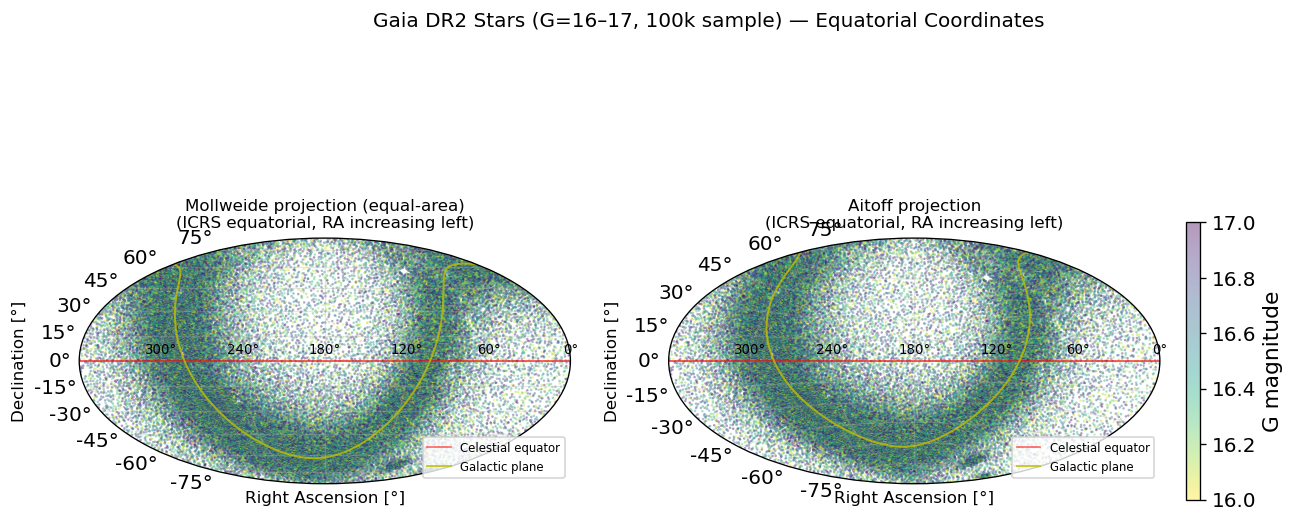

Figure saved.


In [12]:
# ================================================================
# Figure 1: All-sky maps in ICRS (equatorial) coordinates
# ================================================================
fig = plt.figure(figsize=(14, 6))

for i, (proj, title) in enumerate([
    ('mollweide', 'Mollweide projection (equal-area)'),
    ('aitoff',    'Aitoff projection'),
]):
    ax = fig.add_subplot(1, 2, i+1, projection=proj)

    sc = ax.scatter(x_eq, y_eq, c=G_mag, cmap='viridis_r',
                    s=0.3, alpha=0.4, vmin=16, vmax=17, rasterized=True)

    # Celestial equator (b=0 in ICRS)
    ra_line = np.linspace(0, 360, 360)
    dec_line = np.zeros(360)
    xl, yl = sky_for_mpl(ra_line, dec_line)
    ax.plot(xl, yl, 'r-', lw=1, alpha=0.6, label='Celestial equator')

    # Galactic plane (b=0)
    l_gp = np.linspace(0, 360, 360)
    b_gp = np.zeros(360)
    sc_gp = SkyCoord(l=l_gp*u.deg, b=b_gp*u.deg, frame='galactic').icrs
    ra_gp = sc_gp.ra.deg
    dec_gp = sc_gp.dec.deg
    # Sort by RA to avoid wrapping artefacts
    order = np.argsort(ra_gp)
    xgp, ygp = sky_for_mpl(ra_gp[order], dec_gp[order])
    ax.plot(xgp, ygp, 'y-', lw=1.2, alpha=0.8, label='Galactic plane')

    ax.set_title(title + '\n(ICRS equatorial, RA increasing left)', fontsize=10)

    # RA tick labels
    ticks_ra = np.array([0, 60, 120, 180, 240, 300])
    ax.set_xticks(np.deg2rad(-(ticks_ra - 180)))
    ax.set_xticklabels([f'{r}°' for r in ticks_ra], fontsize=8)
    ax.set_xlabel('Right Ascension [°]', fontsize=10)
    ax.set_ylabel('Declination [°]', fontsize=10)

    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=fig.axes, label='G magnitude', shrink=0.5, pad=0.02)
plt.suptitle('Gaia DR2 Stars (G=16–17, 100k sample) — Equatorial Coordinates', fontsize=12)
plt.savefig('coord_allsky_equatorial.pdf', bbox_inches='tight')
plt.show()
print('Figure saved.')

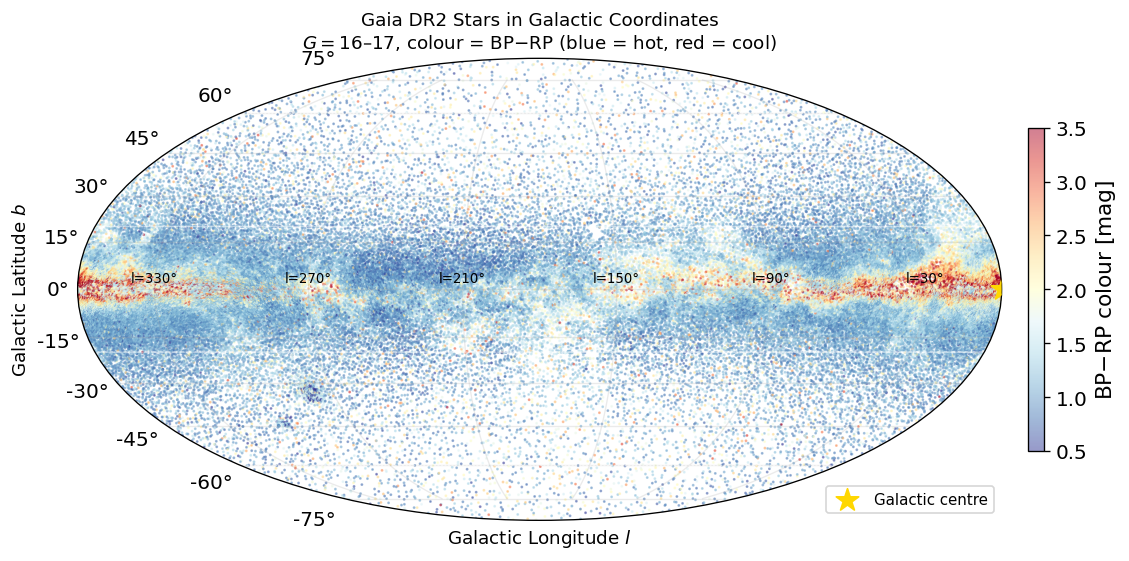

Galactic map: the Milky Way disk stands out as the bright band across the middle.


In [13]:
# ================================================================
# Figure 2: Galactic coordinate map — the Milky Way structure
# ================================================================
fig, ax = plt.subplots(figsize=(14, 5), subplot_kw={'projection': 'mollweide'})

# Colour by BP-RP colour (stellar colour index)
bp_rp = BP_mag - RP_mag
has_color = np.isfinite(bp_rp)

sc = ax.scatter(x_gal[has_color], y_gal[has_color],
                c=bp_rp[has_color], cmap='RdYlBu_r',
                s=0.5, alpha=0.5, vmin=0.5, vmax=3.5, rasterized=True)

# Mark Galactic centre
xgc, ygc = sky_for_mpl(np.array([0.0]), np.array([0.0]))
ax.scatter(xgc, ygc, color='gold', s=200, marker='*', zorder=5, label='Galactic centre')

# Galactic latitude lines at |b|=20° and |b|=60°
for b_lat, ls in [(-20,'--'), (20,'--'), (-60,':'), (60,':')]:
    l_arr = np.linspace(0, 360, 360)
    b_arr = np.full(360, b_lat)
    xl, yl = sky_for_mpl(l_arr, b_arr)
    ax.plot(xl, yl, color='white', ls=ls, lw=0.8, alpha=0.5)

ax.set_title('Gaia DR2 Stars in Galactic Coordinates\n'
             r'$G = 16–17$, colour = BP$-$RP (blue = hot, red = cool)',
             fontsize=11)

# Longitude axis labels
ax.set_xticks(np.deg2rad([-150, -90, -30, 30, 90, 150]))
ax.set_xticklabels(['l=330°', 'l=270°', 'l=210°', 'l=150°', 'l=90°', 'l=30°'], fontsize=8)
ax.set_xlabel('Galactic Longitude $l$', fontsize=11)
ax.set_ylabel('Galactic Latitude $b$', fontsize=11)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=9, loc='lower right')

plt.colorbar(sc, ax=ax, label='BP$-$RP colour [mag]', shrink=0.7, pad=0.02)
plt.savefig('coord_galactic_mollweide.pdf', bbox_inches='tight')
plt.show()
print('Galactic map: the Milky Way disk stands out as the bright band across the middle.')

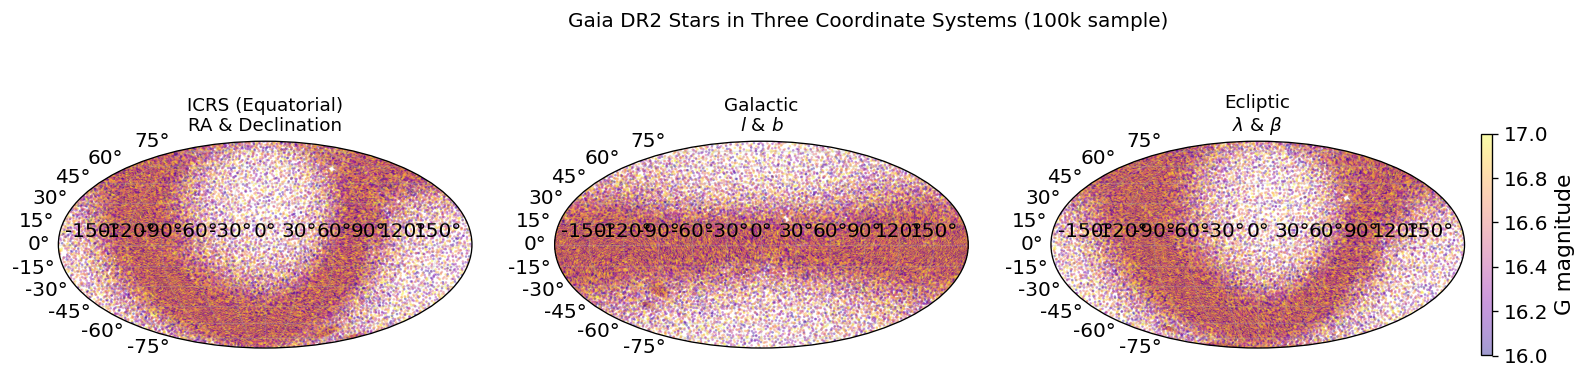

In [14]:
# ================================================================
# Figure 3: Three coordinate systems side by side
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4),
                         subplot_kw={'projection': 'mollweide'})

# Color by G magnitude
cmap_mag = 'plasma'

configs = [
    (x_eq,  y_eq,  'ICRS (Equatorial)\nRA & Declination'),
    (x_gal, y_gal, 'Galactic\n$l$ & $b$'),
    (x_ecl, y_ecl, 'Ecliptic\n$\\lambda$ & $\\beta$'),
]

for ax, (x, y, title) in zip(axes, configs):
    sc = ax.scatter(x, y, c=G_mag, cmap=cmap_mag, s=0.3, alpha=0.4,
                    vmin=16, vmax=17, rasterized=True)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25)

plt.colorbar(sc, ax=axes, label='G magnitude', shrink=0.6, pad=0.01)
plt.suptitle('Gaia DR2 Stars in Three Coordinate Systems (100k sample)', fontsize=12)
plt.savefig('coord_three_systems.pdf', bbox_inches='tight')
plt.show()

---

## 11. Stellar density map with HEALPix

**HEALPix** (Hierarchical Equal Area isoLatitude PIXelization) divides the sphere into pixels of **equal area**, making it ideal for statistical analysis of sky distributions.

The resolution is controlled by `nside` (a power of 2):
- The total number of pixels is $N_{\rm pix} = 12 \times N_{\rm side}^2$
- The pixel area is $\Omega_{\rm pix} = 4\pi / N_{\rm pix}$ sr

For a density map, we:
1. Assign each star to its HEALPix pixel
2. Count stars per pixel
3. Divide by pixel area to get surface density [stars/deg²]

Since our sample is $1/789$ of the full catalog, the density estimate must be scaled accordingly.

Reference: Górski et al. (2005), ApJ 622, 759 — [https://doi.org/10.1086/427976](https://doi.org/10.1086/427976)

In [15]:
# Build a stellar density map
NSIDE_MAP = 64   # 49,152 pixels, each ~0.84 deg^2
NPIX = hp.nside2npix(NSIDE_MAP)
PIX_AREA = hp.nside2pixarea(NSIDE_MAP, degrees=True)  # deg^2

print(f'HEALPix map: Nside={NSIDE_MAP}, Npix={NPIX:,}, pixel area={PIX_AREA:.2f} deg²')

# Assign each star to a pixel (Galactic coordinates)
pix_gal = hp.ang2pix(NSIDE_MAP, l, b, lonlat=True)
pix_eq  = hp.ang2pix(NSIDE_MAP, ra, dec, lonlat=True)

# Count stars per pixel
density_gal = np.zeros(NPIX)
for p in pix_gal:
    density_gal[p] += 1

# Scale to full catalog density [stars/deg^2]
# Our sample is 1/stride of the full catalog
density_gal_scaled = density_gal * stride / PIX_AREA

# Mask empty pixels
density_gal_masked = np.where(density_gal > 0, density_gal_scaled, hp.UNSEEN)

print(f'\nDensity statistics (non-empty pixels):')
good = density_gal_scaled > 0
print(f'  Min  : {density_gal_scaled[good].min():.1f} stars/deg²')
print(f'  Max  : {density_gal_scaled[good].max():.1f} stars/deg²')
print(f'  Mean : {density_gal_scaled[good].mean():.1f} stars/deg²')

HEALPix map: Nside=64, Npix=49,152, pixel area=0.84 deg²

Density statistics (non-empty pixels):
  Min  : 940.1 stars/deg²
  Max  : 134430.9 stars/deg²
  Mean : 3246.7 stars/deg²


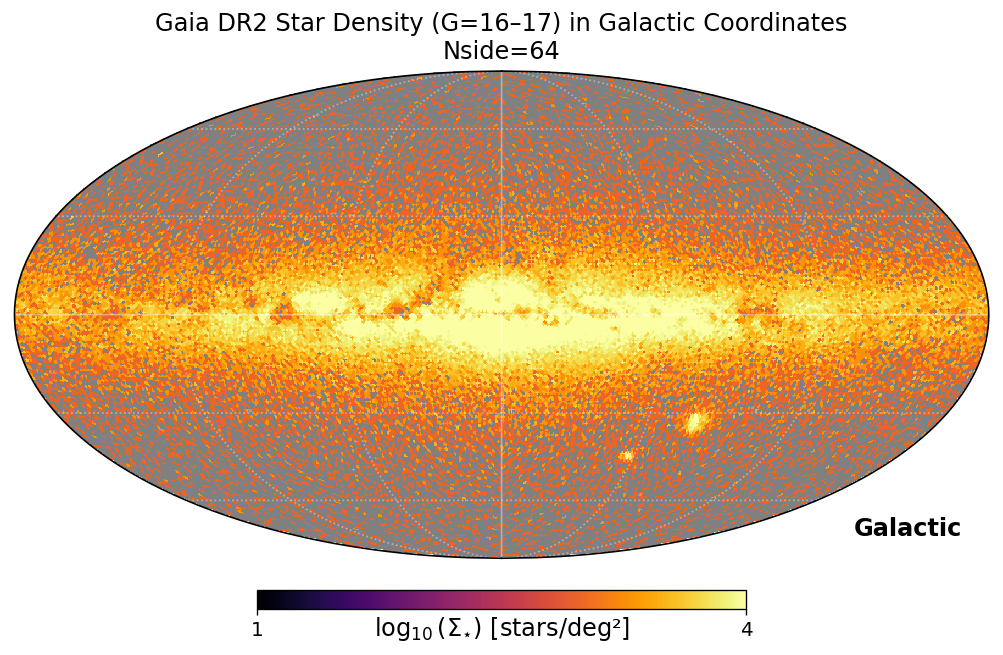

The Galactic disk is clearly visible as the bright horizontal band.
The Galactic centre (l=0, b=0) is the brightest region.


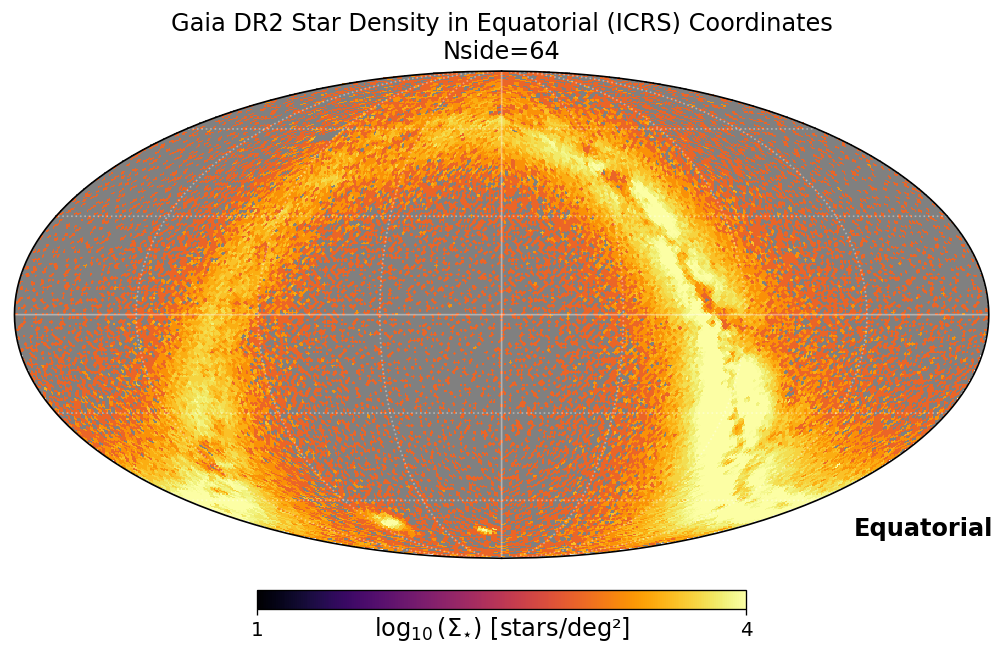

In [16]:
# Plot the density map using healpy's built-in mollweide view
hp.mollview(
    np.log10(np.where(density_gal_masked > 0, density_gal_masked, np.nan)),
    coord=['G'],           # Galactic coordinates
    title=f'Gaia DR2 Star Density (G=16–17) in Galactic Coordinates\nNside={NSIDE_MAP}',
    cmap='inferno',
    unit=r'$\log_{10}(\Sigma_{\star})$ [stars/deg²]',
    min=1, max=4,
    rot=[0, 0, 0],  # centre at (l=0, b=0)
)
hp.graticule(dpar=30, dmer=60, alpha=0.4, color='white')
plt.savefig('coord_healpix_density_galactic.pdf', bbox_inches='tight')
plt.show()

print('The Galactic disk is clearly visible as the bright horizontal band.')
print('The Galactic centre (l=0, b=0) is the brightest region.')

# Also show in equatorial coordinates
density_eq = np.zeros(NPIX)
for p in pix_eq:
    density_eq[p] += 1
density_eq_scaled = density_eq * stride / PIX_AREA

hp.mollview(
    np.log10(np.where(density_eq_scaled > 0, density_eq_scaled, np.nan)),
    coord=['C'],           # C = Celestial = ICRS
    title=f'Gaia DR2 Star Density in Equatorial (ICRS) Coordinates\nNside={NSIDE_MAP}',
    cmap='inferno',
    unit=r'$\log_{10}(\Sigma_{\star})$ [stars/deg²]',
    min=1, max=4,
)
hp.graticule(dpar=30, dmer=45, alpha=0.4, color='white')
plt.savefig('coord_healpix_density_equatorial.pdf', bbox_inches='tight')
plt.show()

---

## 12. Angular separations and spherical geometry

The angular separation between two points $(\alpha_1, \delta_1)$ and $(\alpha_2, \delta_2)$ on the sphere is given by the **haversine formula**:

$$\cos(\Delta\theta) = \sin\delta_1\sin\delta_2 + \cos\delta_1\cos\delta_2\cos(\Delta\alpha)$$

astropy computes this correctly with `SkyCoord.separation()`.

In [17]:
# Compute angular separations from the Galactic centre
gc = SkyCoord(l=0*u.deg, b=0*u.deg, frame='galactic').icrs  # Galactic centre in ICRS

# Angular separation of each star from the Galactic centre
sep_from_gc = coords_icrs.separation(gc)  # returns Angle objects
sep_deg = sep_from_gc.deg

print('Angular separations from the Galactic centre:')
print(f'  Min  : {sep_deg.min():.2f}°')
print(f'  Max  : {sep_deg.max():.2f}°')
print(f'  Mean : {sep_deg.mean():.2f}°')
print(f'  Median: {np.median(sep_deg):.2f}°')

# Cross-match: find nearest neighbours within a small sample
N_CROSS = 1_000
sample1 = coords_icrs[:N_CROSS]
sample2 = coords_icrs[N_CROSS:2*N_CROSS]

# Match each star in sample1 to its nearest neighbor in sample2
idx, sep2d, _ = sample1.match_to_catalog_sky(sample2)
print(f'\nCross-match of {N_CROSS} stars against {N_CROSS} other stars:')
print(f'  Median nearest-neighbour separation: {np.median(sep2d.arcmin):.2f} arcmin')
print(f'  Min   nearest-neighbour separation: {np.min(sep2d.arcsec):.2f} arcsec')

Angular separations from the Galactic centre:
  Min  : 0.17°
  Max  : 179.50°
  Mean : 64.36°
  Median: 55.67°

Cross-match of 1000 stars against 1000 other stars:
  Median nearest-neighbour separation: 990.75 arcmin
  Min   nearest-neighbour separation: 1250.22 arcsec


---

## 13. Summary

### Key coordinate systems

| System | astropy frame | Main coordinates |
|--------|--------------|------------------|
| Equatorial (ICRS) | `'icrs'` | `ra`, `dec` |
| Galactic | `'galactic'` | `l`, `b` |
| Ecliptic | `GeocentricMeanEcliptic` | `lon`, `lat` |
| Horizontal | `AltAz` | `alt`, `az` |

### astropy SkyCoord workflow

```python
from astropy.coordinates import SkyCoord
import astropy.units as u

# Create
c = SkyCoord(ra=180.0*u.deg, dec=+45.0*u.deg, frame='icrs')

# Convert
gal = c.galactic          # Galactic: c.galactic.l, c.galactic.b
ecl = c.geocentricmeanecliptic  # Ecliptic

# Angular distance
other = SkyCoord(ra=270.0*u.deg, dec=-30.0*u.deg, frame='icrs')
sep = c.separation(other)  # returns Angle in degrees/radians/etc.
```

### Further reading

- **astropy coordinates documentation:** [https://docs.astropy.org/en/stable/coordinates/index.html](https://docs.astropy.org/en/stable/coordinates/index.html)
- **Gaia DR2 paper:** Gaia Collaboration, Brown et al. (2018), A&A 616, A1 — [arXiv:1804.09365](https://arxiv.org/abs/1804.09365)
- **HEALPix:** Górski et al. (2005), ApJ 622, 759 — [https://doi.org/10.1086/427976](https://doi.org/10.1086/427976)

### Exercises

1. **Coordinate conversion:** Convert the position of the Andromeda galaxy ($\alpha = 10.68°$, $\delta = 41.27°$) to Galactic and Ecliptic coordinates. What does its Galactic latitude tell you about its location relative to the Milky Way plane?

2. **Circumpolar stars:** From Garching (latitude 48.26°N), which stars (what declination range) are circumpolar (never set)? Verify with astropy.

3. **Parallax and distance:** Find all stars with parallax $\varpi > 2$ mas (distance $< 500$ pc) and plot their positions in Galactic coordinates. Are they concentrated near the plane?

4. **Proper motion map:** Create a quiver plot showing proper motion vectors in a small region of the sky (e.g., $|b| > 60°$). Do you see any kinematic substructure?

5. **Density asymmetry:** The stellar density is much higher near $l \approx 0°$ (Galactic centre direction) than $l \approx 180°$ (anticentre). Quantify this asymmetry by computing the mean density in the two hemispheres.